## IN_DATA
- `dat_traj`

## OUT_DATA
- `dat_map_{job}`

## VERSION

## PACKAGE

In [38]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.sparsemap import *

warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## BASH PARAMETERS

In [39]:
out_dir = project_dir / "results"

if not os.path.exists(out_dir):
    os.makedirs(out_dir)

## LOCAL PARAMETERS

In [40]:
method = 'nearest_neighbor_limit' # 'score_map', 'nearest_neighbor_limit'

## LOAD

In [41]:
# load tile trajectories
dat_traj_dict = pickle.load(open(project_dir / "results" / "dat_traj_dict", "rb"))

## SPECIFY ONE JOB BATCH
1. Select a subset of `dat_traj_dict` with a `pi_level` as a batch of jobs to run on cluster
2. the key for reading `dat_traj_dict` is `(type_id, id_1, id_2)` to output the value `(s_traj, a_traj, occ_map, s_top, xy_traj)`
3. for loading a mouse trajectory, use:
    - `type_id = 1`
    - `id_1` = 3 or 4 or ... (mouse_id)
    - `id_2` = 0 or 1 ... or 5 (rotation_id)
4. for loading a random trajectory, use:
    - `type_id = 0`
    - `id_1` = 0 or 1 or ... (seed)
    - `id_2` = -1 (-1 to specify n/a)
5. load a job as a nested tuple `((type_id, id_1, id_2), pi_level)`

In [42]:
# FULL PILOT BATCH: 10 pi_level, 6 traj for one mouse x 2 + 5 random trajectories (170 jobs, 16K walltime)
seed_list = np.arange(5)
rotation_id_list = np.arange(6)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,seed,-1), pi_lev) for pi_lev in pi_level_list for seed in seed_list]
job_list_mouse_3 = [((1,3,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]
job_list_mouse_4 = [((1,4,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]

# pack
job_batch_optmap = {i+1: job for i, job in enumerate(job_list_rand + job_list_mouse_3 + job_list_mouse_4)}
len(job_batch_optmap)

170

In [43]:
# RANDOM MAP BATCH: 10 pi_level, 2 mice x 5 random maps + 5 random trajectories x 5 random maps (350 jobs)
traj_seed_list = np.arange(5)
map_seed_list = np.arange(5)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,traj_seed,-1), pi_lev, map_seed) for pi_lev in pi_level_list for traj_seed in traj_seed_list for map_seed in map_seed_list]
job_list_mouse_3 = [((1,3,0), pi_lev, map_seed) for pi_lev in pi_level_list for map_seed in map_seed_list]
job_list_mouse_4 = [((1,4,0), pi_lev, map_seed) for pi_lev in pi_level_list for map_seed in map_seed_list]

# pack
job_batch_randmap = {i+1: job for i, job in enumerate(job_list_rand + job_list_mouse_3 + job_list_mouse_4)}
len(job_batch_randmap)

350

## PREP
### setting up belief distribution propagation

In [44]:
# prep: maze dictionaries
hex_0_grid, hex_1_grid, s_z_dict, s_hex_dict, hex_a_dict, xy_s_dict, a_dict, sas_dict, ssa_dict, s_nbr_dict = load_maze_dicts(maze)
xy_tile_all = np.array([(hex_0_grid[y,x], hex_1_grid[y,x]) for (x,y), s in xy_s_dict.items()])

# prep: map
e_sh_arr = get_e_sh_arr(n_tiles, ringsize)
eid_wall, sh_wall, n_edges_wall = get_eid_wall(sas_dict, ringsize, n_tiles, e_sh_arr)
sh_dz_arr = get_sh_dz_arr(s_z_dict, sas_dict, sh_wall)
pq_mask_amb_dict = get_pq_mask_dict_for_ambiguous_edges(sh_dz_arr)

# prep: pi & tile transition tensor
pi_all = get_p_vonmises_for_enumPI()
T = get_T_tensor(sas_dict, ringsize, n_tiles)
T_dict = get_T_tensor_dict(T, ringsize)

## RUN SINGLE

In [45]:
load_dir = project_dir / "results" / "data_optmap"
job_id = 93 # 105,46; 99,41; 93,36; 87,31
mapsize = 67  # 13,14; 39,41; 68,71

# load job
job = job_batch_optmap[job_id]

In [46]:
# load_dir = project_dir / "results" / "data_randmap"
# job_id = 286 # 286, 176, 181
# mapsize = 67

# # load job
# job = job_batch_randmap[job_id]

In [47]:
# load one job
s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[job[0]]
map_iter, mapsize_iter, score_map_iter, score_iter = load_maps_from_one_job(load_dir, job, n_edges)

# load one map so that score≈0.7
map, score_map, score, n_edges_map = load_one_map(mapsize, map_iter, mapsize_iter, score_iter, score_map_iter, e_sh_arr, sh_dz_arr)

# get diffusion radius
sigma_tile = get_sigma_tile(score_map, xy_tile_all, method=method)

# get tile locality, ambiguity, identifiability
L_mat, A_mat, I_mat_local = get_locality_ambiguity_identifiability(map, sigma_tile, xy_tile_all, sh_dz_arr, e_sh_arr)

# get infomap
infomap, info_mean = get_infomap(L_mat, A_mat, I_mat_local, s_top, n_edges_map, mapsize, score_map, method=method)

# print
info_mean

0.4078024513296944

## TEST SINGLE

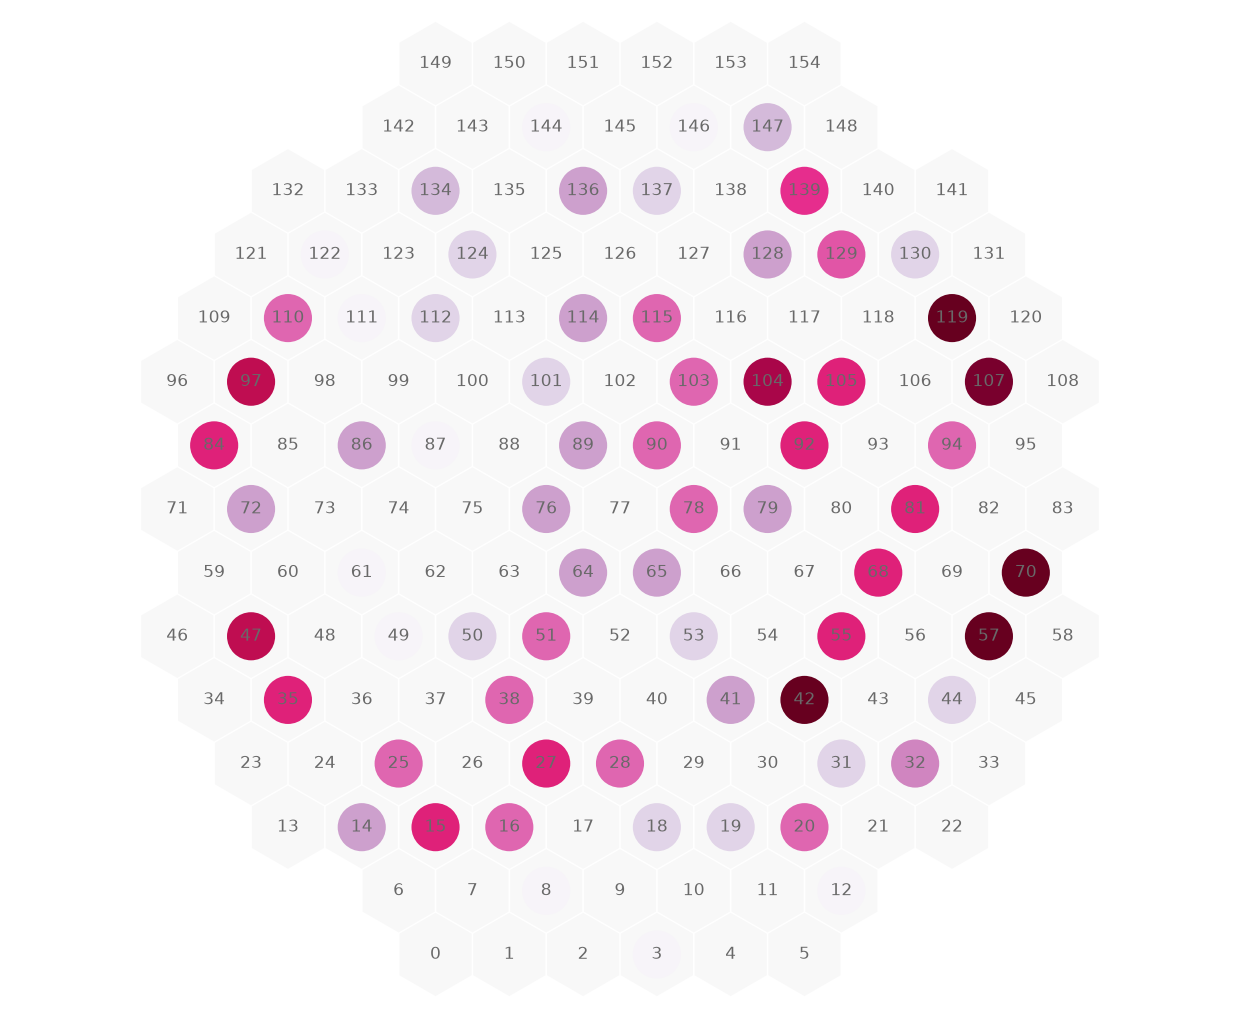

In [48]:
# # prep
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T

# plot
plt.figure(figsize=(6.3,5.2), dpi=200)

# map
plt.scatter(hex_0_all, hex_1_all, marker='h', c='lightgray', s=900, edgecolor='none', alpha=.15)

plt.scatter(hex_0_all, hex_1_all, c=infomap, cmap='PuRd', marker='o', s=300*n_edges_map, vmin=0, vmax=1, edgecolor='none')
# plt.colorbar()

for (x,y), s in xy_s_dict.items():
    plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')

# setting
plt.axis('off')
plt.axis('equal')
plt.tight_layout()

## RUN ALL

In [49]:
def run_mp(para):
    # load
    job_id, label = para
    if label == "optmap":
        load_dir = project_dir / "results" / "data_optmap"
        job = job_batch_optmap[job_id]
    elif label == "randmap":
        load_dir = project_dir / "results" / "data_randmap"
        job = job_batch_randmap[job_id]
    
    # load one job
    s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[job[0]]
    map_iter, mapsize_iter, score_map_iter, score_iter = load_maps_from_one_job(load_dir, job, n_edges)
    
    # iter
    infomap_list = []
    info_mean_list = []
    for mapsize in mapsize_iter:
        # load one map so that score≈0.7
        map, score_map, score, n_edges_map = load_one_map(mapsize, map_iter, mapsize_iter, score_iter, score_map_iter, e_sh_arr, sh_dz_arr)
        
        # get diffusion radius
        sigma_tile = get_sigma_tile(score_map, xy_tile_all, method=method)

        # get tile locality, ambiguity, identifiability
        L_mat, A_mat, I_mat_local = get_locality_ambiguity_identifiability(map, sigma_tile, xy_tile_all, sh_dz_arr, e_sh_arr)

        # get infomap
        infomap, info_mean = get_infomap(L_mat, A_mat, I_mat_local, s_top, n_edges_map, mapsize, score_map, method=method)
        
        # append
        infomap_list.append(infomap)
        info_mean_list.append(info_mean)
    return mapsize_iter, infomap_list, info_mean_list

### optmap

In [50]:
# run (4m30s for 170jobs)
if method == 'score_map':
    if not os.path.exists(out_dir / 'dat_infomap_optmap'):
        param = [(job_id, 'optmap') for job_id in list(job_batch_optmap)]
        with multiprocess.Pool() as pool:
            mapsize_iter_all, infomap_all, info_mean_all = zip(*pool.map(run_mp, param))
            
        # pack
        mapsize_iter = mapsize_iter_all[0]
        infomap_all = np.array(infomap_all)
        info_mean_all = np.array(info_mean_all)
        dat_infomap_optmap = mapsize_iter, infomap_all, info_mean_all

### randmap

In [51]:
# run (9m for 350jobs)
if method == 'score_map':
    if not os.path.exists(out_dir / 'dat_infomap_randmap'):
        param = [(job_id, 'randmap') for job_id in list(job_batch_randmap)]
        with multiprocess.Pool() as pool:
            mapsize_iter_all, infomap_all, info_mean_all = zip(*pool.map(run_mp, param))

        # pack
        mapsize_iter = mapsize_iter_all[0]
        infomap_all = np.array(infomap_all)
        info_mean_all = np.array(info_mean_all)
        dat_infomap_randmap = mapsize_iter, infomap_all, info_mean_all

### optmap, nearest neighbor limit

In [52]:
# run (4m30s for 170jobs)
if method == 'nearest_neighbor_limit':
    if not os.path.exists(out_dir / 'dat_infomap_optmap_nn'):
        param = [(job_id, 'optmap') for job_id in list(job_batch_optmap)]
        with multiprocess.Pool() as pool:
            mapsize_iter_all, infomap_all, info_mean_all = zip(*pool.map(run_mp, param))
            
        # pack
        mapsize_iter = mapsize_iter_all[0]
        infomap_all = np.array(infomap_all)
        info_mean_all = np.array(info_mean_all)
        dat_infomap_optmap_nn = mapsize_iter, infomap_all, info_mean_all

### randmap, nearest neighbor limit

In [53]:
# run (9m for 350jobs)
if method == 'nearest_neighbor_limit':
    if not os.path.exists(out_dir / 'dat_infomap_randmap_nn'):
        param = [(job_id, 'randmap') for job_id in list(job_batch_randmap)]
        with multiprocess.Pool() as pool:
            mapsize_iter_all, infomap_all, info_mean_all = zip(*pool.map(run_mp, param))

        # pack
        mapsize_iter = mapsize_iter_all[0]
        infomap_all = np.array(infomap_all)
        info_mean_all = np.array(info_mean_all)
        dat_infomap_randmap_nn = mapsize_iter, infomap_all, info_mean_all

## PICKLE

In [54]:
if method == 'score_map':
    if not os.path.exists(out_dir / 'dat_infomap_optmap'):
        pickle.dump(dat_infomap_optmap, open(out_dir / 'dat_infomap_optmap', "wb"))
    else:
        dat_infomap_optmap = pickle.load(open(out_dir / 'dat_infomap_optmap', "rb"))

In [55]:
if method == 'score_map':
    if not os.path.exists(out_dir / 'dat_infomap_randmap'):
        pickle.dump(dat_infomap_randmap, open(out_dir / 'dat_infomap_randmap', "wb"))
    else:
        dat_infomap_randmap = pickle.load(open(out_dir / 'dat_infomap_randmap', "rb"))

In [56]:
if method == 'nearest_neighbor_limit':
    if not os.path.exists(out_dir / 'dat_infomap_optmap_nn'):
        pickle.dump(dat_infomap_optmap_nn, open(out_dir / 'dat_infomap_optmap_nn', "wb"))
    else:
        dat_infomap_optmap_nn = pickle.load(open(out_dir / 'dat_infomap_optmap_nn', "rb"))

In [57]:
if method == 'nearest_neighbor_limit':
    if not os.path.exists(out_dir / 'dat_infomap_randmap_nn'):
        pickle.dump(dat_infomap_randmap_nn, open(out_dir / 'dat_infomap_randmap_nn', "wb"))
    else:
        dat_infomap_randmap_nn = pickle.load(open(out_dir / 'dat_infomap_randmap_nn', "rb"))